# ModelComparison-FraudDetection_Credit_Card

In [20]:
# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [21]:
# 2. Load the data
file_path = r"C:\Users\Windows10 Pro\Downloads\DataScience_AI\2025\4. Jul2025\07072025\7th - SVM\SVM - internship project_ dataset has given\project\default of credit card clients.xls"
data = pd.read_excel(file_path, header=1)  # Skipping the top header row if needed

In [25]:
# 3. Preprocess the data
data.rename(columns={data.columns[-1]: "default"}, inplace=True)  # Last column is target
X = data.drop(columns=["ID", "default"])  # Drop ID and target
y = data["default"]


# Ensure y is in correct shape and type
y = y.squeeze()

In [26]:
# 4. Split the data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 5. Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
# 6. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []  # Store metrics

Training Model: Logistic Regression


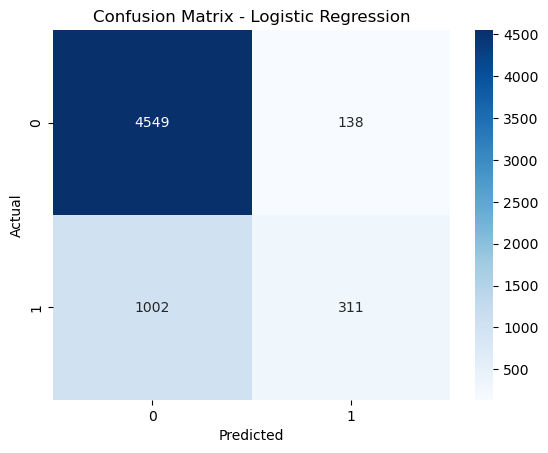

Accuracy: 0.8100
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

--------------------------------------------------
Training Model: Support Vector Machine


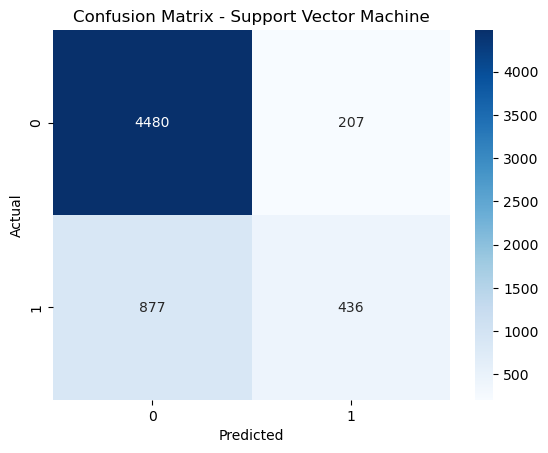

Accuracy: 0.8193
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.33      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000

--------------------------------------------------
Training Model: Decision Tree


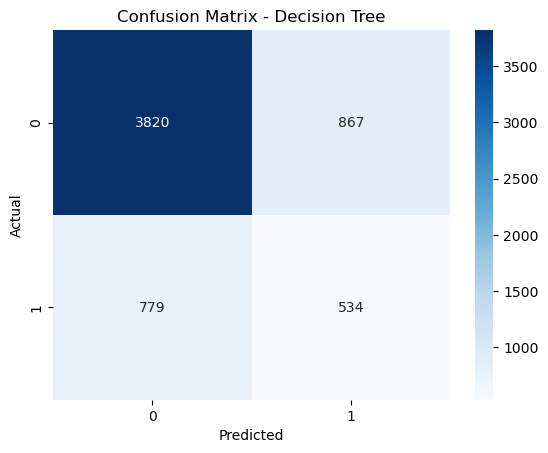

Accuracy: 0.7257
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4687
           1       0.38      0.41      0.39      1313

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000

--------------------------------------------------


In [29]:
# 7. Train and evaluate
for name, model in models.items():
    print(f"Training Model: {name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Accuracy metrics
    com = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    bias = model.score(x_train, y_train)
    variance = model.score(x_test, y_test)

    # Visualize confusion matrix
    sns.heatmap(data=com, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Save results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Bias (Train Score)': bias,
        'Variance (Test Score)': variance
    })
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(cr)
    print("-" * 50)

In [30]:
# 8. Display summary results
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)


Model Comparison:
                    Model  Accuracy  Bias (Train Score)  Variance (Test Score)
0     Logistic Regression  0.810000            0.810875               0.810000
1  Support Vector Machine  0.819333            0.825292               0.819333
2           Decision Tree  0.725667            0.999458               0.725667
